# **<span style="color:blue">Notebook 1 - Prof. Dr. Humberto Elias Lopes - Sintetizando Dados para uma Variável Categorizada</span>**
## <span style="color:blue"> 1) Distribuição de Frequências </span>

A distribuição de frequências é um resumo tabular de dados mostrando o número (frequência) de observações em cada uma das diversas classes não sobrepostas. (Anderson et. al., 2021, p. 29).

Na prática, ela é um recurso poderoso para que entendamos o comportamento de dados categorizados, ou seja, de dados armazenados em variáveis qualitativas, mensuradas no nível nominal ou ordinal.

### **<span style="color:green">Na Prática 1.1</span>**:  Criando uma distribuição para o consumo de marcas de refrigerante. 

O livro-texto da disciplina apresenta um problema prático por meio da Tabela 2.1. Nela, temos dados de uma amostra de 50 compras de refrigerantes em determinada localidade nos Estados Unidos. Nossa tarefa é criarmos uma tabela de distribuição de frequências usando a linguagem Python.

O conjunto de dados está em um arquivo do Excel, armazenado no repositório do GitHub que o professor compartilhou com sua turma. o link para acessar este diretório está no Canvas.

In [7]:
import pandas as pd

# 1. Carregamento dos dados a partir do repositório remoto
url = "https://github.com/humbertoeliaslopes/AD_negocios/blob/main/bebidas.xlsx?raw=true"
df = pd.read_excel(url)

# 2. Obtenção das distribuições de frequência
freq_absoluta = df['marcas_compradas'].value_counts()
freq_relativa = df['marcas_compradas'].value_counts(normalize=True)
freq_percentual = freq_relativa * 100

# 3. Consolidação no DataFrame
tabela_frequencia = pd.DataFrame({
    'Frequência Absoluta': freq_absoluta,
    'Frequência Relativa': freq_relativa,
    'Frequência Percentual': freq_percentual
})

# 4. Inserção da linha de Total
total_abs = tabela_frequencia['Frequência Absoluta'].sum()
total_rel = tabela_frequencia['Frequência Relativa'].sum()
total_perc = tabela_frequencia['Frequência Percentual'].sum()

tabela_frequencia.loc['Total'] = [total_abs, total_rel, total_perc]
tabela_frequencia.index.name = 'Marcas de Refrigerante'

# 5. Formatação rigorosa com duas casas decimais
tabela_formatada = tabela_frequencia.copy()
tabela_formatada['Frequência Absoluta'] = tabela_formatada['Frequência Absoluta'].astype(int)
tabela_formatada['Frequência Relativa'] = tabela_formatada['Frequência Relativa'].apply(lambda x: f"{x:.2f}".replace('.', ','))
tabela_formatada['Frequência Percentual'] = tabela_formatada['Frequência Percentual'].apply(lambda x: f"{x:.2f}%".replace('.', ','))

# Exibição da tabela final
print(tabela_formatada)

                        Frequência Absoluta Frequência Relativa  \
Marcas de Refrigerante                                            
Coca-Cola                                19                0,38   
Pepsi                                    13                0,26   
Diet Coke                                 8                0,16   
Dr. Pepper                                5                0,10   
Sprite                                    5                0,10   
Total                                    50                1,00   

                       Frequência Percentual  
Marcas de Refrigerante                        
Coca-Cola                             38,00%  
Pepsi                                 26,00%  
Diet Coke                             16,00%  
Dr. Pepper                            10,00%  
Sprite                                10,00%  
Total                                100,00%  


Como você pode perceber, já temos a tabela, mas ela não está formatada no padrão da ABNT. Vamos refazer o código, para que ele incorpore essa demanda.

In [8]:
import pandas as pd

# 1. Carregamento dos dados do repositório remoto
url = "https://github.com/humbertoeliaslopes/AD_negocios/blob/main/bebidas.xlsx?raw=true"
df = pd.read_excel(url)

# 2. Obtenção das distribuições de frequência
# Frequência Absoluta (f_i)
freq_abs = df['marcas_compradas'].value_counts()

# Frequência Relativa (f_i / n)
freq_rel = df['marcas_compradas'].value_counts(normalize=True)

# Frequência Percentual ((f_i / n) * 100)
freq_perc = freq_rel * 100

# 3. Consolidação no DataFrame estruturado
tabela = pd.DataFrame({
    'Frequência Absoluta': freq_abs,
    'Frequência Relativa': freq_rel,
    'Frequência Percentual': freq_perc
})

# 4. Inserção da linha de Total
total_abs = tabela['Frequência Absoluta'].sum()
total_rel = tabela['Frequência Relativa'].sum()
total_perc = tabela['Frequência Percentual'].sum()

tabela.loc['Total'] = [total_abs, total_rel, total_perc]

# 5. Nomeação do índice categórico
tabela.index.name = 'Marcas de Refrigerante'

# 6. Aplicação da estilização conforme diretrizes ABNT/IBGE
tabela_abnt = (
    tabela.style
    .format({
        'Frequência Absoluta': '{:,.0f}',
        'Frequência Relativa': '{:.2f}',
        'Frequência Percentual': '{:.2f}%'
    })
    .set_table_styles([
        # Linha superior da tabela e separação do cabeçalho
        {'selector': 'thead', 'props': [('border-top', '2px solid black'), ('border-bottom', '1px solid black')]},
        # Cabeçalhos das colunas
        {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold'), ('background-color', 'white')]},
        # Linha inferior de fechamento e formatação da linha de total
        {'selector': 'tbody tr:last-child', 'props': [('border-top', '1px solid black'), ('border-bottom', '2px solid black'), ('font-weight', 'bold')]},
        # Formatação e alinhamento das células numéricas à direita
        {'selector': 'td', 'props': [('border', 'none'), ('text-align', 'right'), ('padding', '6px 14px')]},
        # Alinhamento do índice categórico à esquerda
        {'selector': 'th.row_heading', 'props': [('text-align', 'left'), ('font-weight', 'normal'), ('border', 'none')]}
    ])
    .set_caption("Tabela 1: Distribuição de frequência das marcas de refrigerante")
)

# 7. Renderização do resultado no Jupyter Notebook
tabela_abnt

,Frequência Absoluta,Frequência Relativa,Frequência Percentual
Marcas de Refrigerante,,,
Coca-Cola,19,0.38,38.00%
Pepsi,13,0.26,26.00%
Diet Coke,8,0.16,16.00%
Dr. Pepper,5,0.10,10.00%
Sprite,5,0.10,10.00%
Total,50,1.00,100.00%


Agora sim! Temos uma tabela visualmente mais atrativa, por seguir as normas da ABNT. 

Nós, porém, temos outra dificuldade: como exportamos essa tabela para um editor de texto (como o Word, por exemplo), sem perder a formatação? Para isso, vamos acrescentar um comando que permitirá exportar um arquivo HTML que será facilmente lido pelo Word (ou outro editor de textos, como o Pages da Apple ou o Documentos, do Google). O comando será este:

# Exporta o HTML da tabela estilizada para um arquivo local
with open("tabela_abnt.html", "w", encoding="utf-8") as f:
    f.write(tabela_abnt.to_html())

Vejamos como ficará nosso código.

In [9]:
import pandas as pd

# 1. Carregamento dos dados brutos a partir do repositório remoto no GitHub
url = "https://github.com/humbertoeliaslopes/AD_negocios/blob/main/bebidas.xlsx?raw=true"
df = pd.read_excel(url)

# 2. Cálculo das distribuições de frequência para a variável qualitativa nominal
# Frequência Absoluta: contagem simples de ocorrências por categoria (f_i)
freq_abs = df['marcas_compradas'].value_counts()

# Frequência Relativa: proporção de cada categoria em relação ao total (f_i / n)
freq_rel = df['marcas_compradas'].value_counts(normalize=True)

# Frequência Percentual: proporção expressa em base centesimal ((f_i / n) * 100)
freq_perc = freq_rel * 100

# 3. Consolidação dos dados no DataFrame base
tabela = pd.DataFrame({
    'Frequência Absoluta': freq_abs,
    'Frequência Relativa': freq_rel,
    'Frequência Percentual': freq_perc
})

# 4. Inserção da linha de consolidação de Totais
total_abs = tabela['Frequência Absoluta'].sum()
total_rel = tabela['Frequência Relativa'].sum()
total_perc = tabela['Frequência Percentual'].sum()

tabela.loc['Total'] = [total_abs, total_rel, total_perc]

# 5. Definição do nome do índice categórico
tabela.index.name = 'Marcas de Refrigerante'

# 6. Aplicação de estilização CSS aderente às normas ABNT e IBGE
tabela_abnt = (
    tabela.style
    .format({
        'Frequência Absoluta': '{:,.0f}',
        'Frequência Relativa': '{:.2f}',
        'Frequência Percentual': '{:.2f}%'
    })
    .set_table_styles([
        # Linha superior da tabela e separador do cabeçalho
        {'selector': 'thead', 'props': [('border-top', '2px solid black'), ('border-bottom', '1px solid black')]},
        # Formatação do cabeçalho das colunas
        {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold'), ('background-color', 'white')]},
        # Linha de fechamento inferior e destaque da linha de Total
        {'selector': 'tbody tr:last-child', 'props': [('border-top', '1px solid black'), ('border-bottom', '2px solid black'), ('font-weight', 'bold')]},
        # Alinhamento e espaçamento das células de dados numéricos
        {'selector': 'td', 'props': [('border', 'none'), ('text-align', 'right'), ('padding', '6px 14px')]},
        # Alinhamento do índice textual à esquerda sem bordas laterais
        {'selector': 'th.row_heading', 'props': [('text-align', 'left'), ('font-weight', 'normal'), ('border', 'none')]}
    ])
    .set_caption("Tabela 1: Distribuição de frequência das marcas de refrigerante")
)

# 7. Exibição da tabela estilizada no Jupyter Notebook
tabela_abnt

# 8. Exportação do HTML estilizado para arquivo local
with open("tabela_abnt.html", "w", encoding="utf-8") as f:
    f.write(tabela_abnt.to_html())

Se tudo deu certo, esse comando criou um arquivo .html no seu dispositivo. Localize-o e abra-o com o editor de texto da sua preferência. Você verá que ele está pronto para ser editado.

Agora temos a tabela que sintetiza nossos dados categorizados medidos na escala nominal. Mas precisamos analisar as informações que essa tabela nos fornece, sem cairmos na banalidade de frases do tipo: "A Coca-Cola é a marca de refrigerante mais vendida nessa amostra." QUALQUER PESSOA consegue perceber isso! Precisamos oferecer algo mais para aqueles que lerão nosso relatório de análise. 

Para evitarmos uma análise banal, usaremos as recomendações de Cole Knaflic no livro "Storytelling com Dados", que eu recomendei na primeira aula da disciplina. Seguindo essas recomendações, nossa análise poderia ser a seguinte:

### **<span style="color:blue">Relatório de Análise Estratégica</span>**: Posicionamento Competitivo no Mercado de Refrigerantes 

***A) Contexto Analítico e Diagnóstico Estrutural da Amostra***

A análise da distribuição de frequências da amostra de 50 consumidores ($n = 50$) revela um mercado altamente concentrado e polarizado, típico de setores maduros de bens de consumo de giro rápido (FMCG). Sob a ótica da estatística descritiva aplicada à tomada de decisão, a variável categórica nominal "Marcas Compradas" demonstra que as preferências do consumidor não se distribuem de forma homogênea, mas se estruturam em três blocos competitivos bem delimitados.

A mensagem central que emerge dos dados é direta: a liderança isolada e o duopólio tradicional de colas capturam quase dois terços do mercado da amostra, confinando as marcas de nicho a uma disputa marginal por espaço de gôndola e volume.

***B) Dinâmica Competitiva da Amostra: Análise por Grupos Estratégicos***

A leitura dos dados permite segmentar o mercado amostrado em três forças concorrenciais distintas: 

**1) Líder absoluta (Coca-Cola com 38,00%):** a marca detém a maior frequência absoluta ($f_i = 19$), posicionando-se como a força dominante isolada. Esse patamar confere à empresa economias de escala em distribuição, poder de barganha substancial sobre os canais de varejo e forte consolidação de share of mind. Sua distância para a concorrente direta é de 12 pontos percentuais.

**2) Desafiante direta (Pepsi com 26,00%):** com 13 preferências registradas, a marca atua como a principal antagonista no segmento de colas tradicionais. Somadas, Coca-Cola e Pepsi concentram 64,00% da preferência total da amostra. Essa taxa de concentração das duas principais marcas evidencia que a barreira de entrada no segmento principal de colas é praticamente intransponível para novos concorrentes sem escala massiva.

**3) Marcas de segmentação e nicho (Diet Coke com 16,00%, Dr. Pepper com 10,00% e Sprite com 10,00%):** as três opções somam 36,00% da preferência. A presença relevante de Diet Coke (8 consumidores) indica uma demanda consolidada por produtos de baixa caloria, operando como uma extensão estratégica de linha da líder para blindar o mercado contra entrantes focados em saudabilidade. Dr. Pepper e Sprite ocupam posições marginais de nicho na amostra, cada uma capturando apenas 5 consumidores. 

Sob a perspectiva corporativa, cabe ressaltar o domínio hegemônico da The Coca-Cola Company, que, ao consolidar as participações de Coca-Cola (38,00%), Diet Coke (16,00%) e Sprite (10,00%), detém 64,00% de todo o volume de escolhas da amostra por meio de uma estratégia multimarca eficaz.

***C) Implicações para a Tomada de Decisão Estratégica***

A conversão da evidência quantitativa em decisão empresarial orienta três diretrizes claras, dependendo da posição do tomador de decisão no tabuleiro competitivo: 

**1) Para a líder de mercado:** a prioridade gerencial não deve ser uma guerra de preços predatória, mas sim a defesa do espaço de gôndola e a retenção de clientes. O investimento deve focar na manutenção da lealdade à marca-mãe e na migração contínua de consumidores para variantes de maior margem (como a linha Diet/Zero).

**2) Para a Desafiante (Pepsi):** enfrentar a líder em escala direta exige investimento desproporcional. A decisão analítica recomenda estratégias de diferenciação de público, agressividade promocional em canais específicos (como redes de fast-food e parcerias exclusivas) e inovação de embalagens para maximizar a conversão no ponto de venda.

**3) Para as Marcas de Nicho e Novos Entrantes (Dr. Pepper e similares):** tentar competir de forma frontal contra o duopólio Coca-Pepsi é economicamente inviável com base nos dados. A postura correta é adotar estratégias genéricas de foco ou especialização: buscar canais de distribuição alternativos, focar em atributos de sabor únicos e explorar ocasiões de consumo diferenciadas em que as marcas líderes possuam menor apelo emocional.

O relatório ficou bom porque usou o conhecimento em estratégia empresarial com os dados. Com essa combinação, um administrador poderia tomar decisões de negócio bem mais fundamentadas.

Apesar disso, há um detalhe que ainda não está bom: de acordo com as recomendações da Cole Knaflic, o título da tabela tem que ser harmônico com o storytelling do relatório de análise. Nós, porém, usamos um chatíssimo "Tabela 1: Distribuição de frequência das marcas de refrigerante". Ele não está errado: longe disso! Mas é banal. Vamos rodar o código com o padrão da ABNT, substituindo este título por outro bem mais interessante. Veja o resultado:

In [11]:
import pandas as pd

# 1. Carregamento dos dados brutos a partir do repositório no GitHub
url = "https://github.com/humbertoeliaslopes/AD_negocios/blob/main/bebidas.xlsx?raw=true"
df = pd.read_excel(url)

# 2. Obtenção das distribuições de frequência
# Frequência Absoluta: contagem de ocorrências por categoria (f_i)
freq_abs = df['marcas_compradas'].value_counts()

# Frequência Relativa: proporção unitária em relação ao total (f_i / n)
freq_rel = df['marcas_compradas'].value_counts(normalize=True)

# Frequência Percentual: proporção em base centesimal ((f_i / n) * 100)
freq_perc = freq_rel * 100

# 3. Consolidação no DataFrame base
tabela = pd.DataFrame({
    'Frequência Absoluta': freq_abs,
    'Frequência Relativa': freq_rel,
    'Frequência Percentual': freq_perc
})

# 4. Inserção da linha de consolidação de Totais
total_abs = tabela['Frequência Absoluta'].sum()
total_rel = tabela['Frequência Relativa'].sum()
total_perc = tabela['Frequência Percentual'].sum()

tabela.loc['Total'] = [total_abs, total_rel, total_perc]

# 5. Definição do nome da coluna categórica (índice)
tabela.index.name = 'Marcas de Refrigerante'

# 6. Estruturação do Título de Ação e Subtítulo (Padrão Storytelling com Dados)
legenda_html = (
    "<div style='text-align: left; margin-bottom: 8px; font-family: Arial, sans-serif;'>"
    "<strong style='font-size: 11pt; color: #1F4E79;'>"
    "Liderança Consolidada: Coca-Cola Detém 38% das Escolhas e Abre Vantagem de 12 Pontos sobre a Vice-Líder"
    "</strong><br>"
    "<span style='font-size: 9.5pt; font-style: italic; color: #555555;'>"
    "Distribuição de frequências das marcas de refrigerante na amostra analisada (n = 50)"
    "</span>"
    "</div>"
)

# 7. Aplicação da estilização conforme diretrizes ABNT/IBGE
tabela_abnt = (
    tabela.style
    .format({
        'Frequência Absoluta': '{:,.0f}',
        'Frequência Relativa': '{:.2f}',
        'Frequência Percentual': '{:.2f}%'
    })
    .set_table_styles([
        # Posicionamento e alinhamento do título e subtítulo no topo
        {'selector': 'caption', 'props': [('caption-side', 'top'), ('text-align', 'left'), ('padding-bottom', '6px')]},
        # Linha superior da tabela e linha delimitadora do cabeçalho
        {'selector': 'thead', 'props': [('border-top', '2px solid black'), ('border-bottom', '1px solid black')]},
        # Cabeçalhos das colunas
        {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold'), ('background-color', 'white')]},
        # Linha de fechamento inferior e destaque da linha de Total
        {'selector': 'tbody tr:last-child', 'props': [('border-top', '1px solid black'), ('border-bottom', '2px solid black'), ('font-weight', 'bold')]},
        # Alinhamento e espaçamento das células de dados numéricos
        {'selector': 'td', 'props': [('border', 'none'), ('text-align', 'right'), ('padding', '6px 14px')]},
        # Alinhamento do índice categórico à esquerda sem bordas laterais
        {'selector': 'th.row_heading', 'props': [('text-align', 'left'), ('font-weight', 'normal'), ('border', 'none')]}
    ])
    .set_caption(legenda_html)
)

# 8. Exibição da tabela estilizada na interface do Jupyter Notebook
tabela_abnt

,Frequência Absoluta,Frequência Relativa,Frequência Percentual
Marcas de Refrigerante,,,
Coca-Cola,19,0.38,38.00%
Pepsi,13,0.26,26.00%
Diet Coke,8,0.16,16.00%
Dr. Pepper,5,0.10,10.00%
Sprite,5,0.10,10.00%
Total,50,1.00,100.00%


Melhorou demais, não é mesmo? Agora temos uma tabela com título e subtítulo condizentes com o storytelling do nosso relatório de análise! Um detalhe nessa versão final do código: lembre-se de acrescentar o chunk que exporta a tabela para o formato HTML. 

## <span style="color:blue"> 2) Gráficos de Barras </span>

Os gráficos de barras podem ser usados no lugar das tabelas (ou em conjunto com elas) para representar o comportamento dos dados em variáveis categorizadas. 

Esses gráficos, na verdade, mostram as frequências (absolutas, relativas e/ou percentuais) de uma forma mais visual. Por essa razão, muitas pessoas (mas não este professor...) preferem usar gráficos de barras no lugar das tabelas.

Os gráficos de barras podem ser bidimensionais ou tridimensionais. O importante é você escolher a alternativa que permitirá a MELHOR visualização dos dados para quem lerá seu relatório. 

Nós já temos o relatório de análise dos dados, escrito a partir da tabela que criamos. Essa tabela, como vimos, tem título e subtítulo bastante atrativos a alinhados com a técnica de storytelling de dados que usamos no relatório. Assim, escreveremos um código que crie um gráfico de barras com o mesmo título e subtítulo da tabela. 

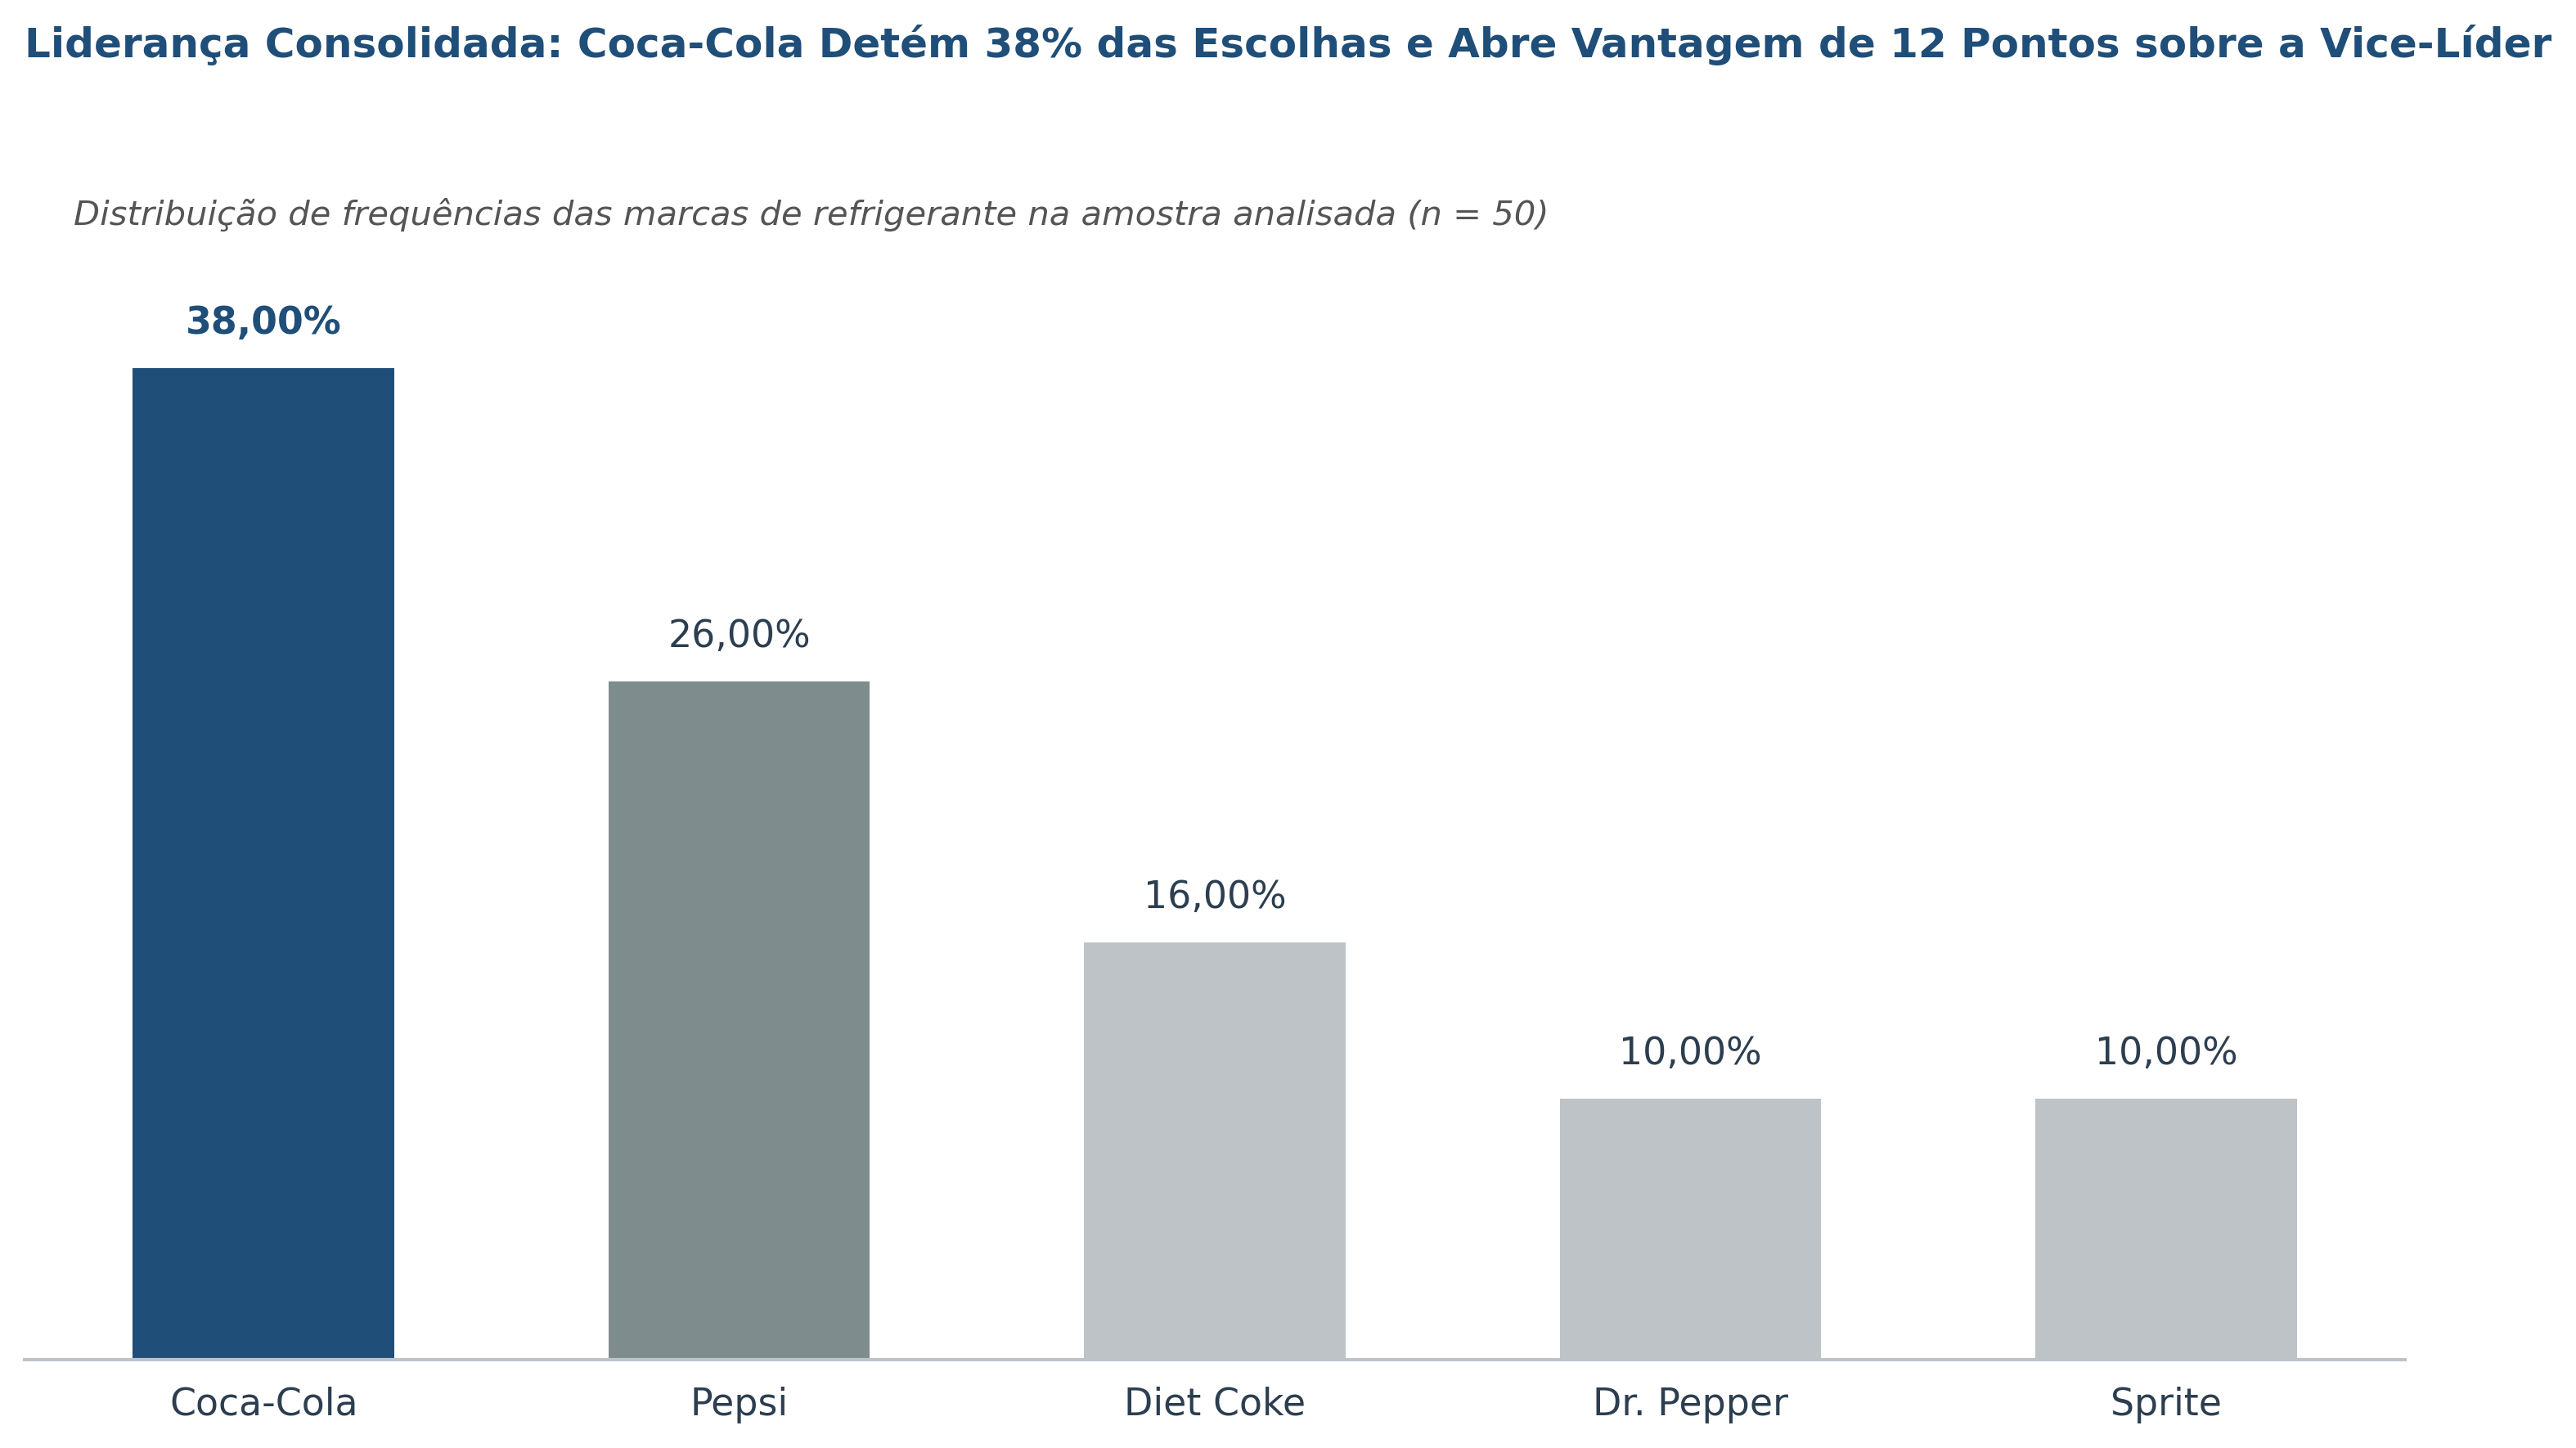

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Carregamento da base de dados remota do GitHub
url = "https://github.com/humbertoeliaslopes/AD_negocios/blob/main/bebidas.xlsx?raw=true"
df = pd.read_excel(url)

# 2. Obtenção da distribuição de frequência percentual (ordenada de forma decrescente)
freq_percentual = (
    df['marcas_compradas']
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
)

# 3. Definição da paleta de cores pré-atentiva
# Azul corporativo para a marca líder, cinza intermediário para a vice-líder e cinza claro para as marcas de nicho
cores = ['#1F4E79', '#7F8C8D', '#BDC3C7', '#BDC3C7', '#BDC3C7']

# 4. Construção da figura e dos eixos
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Renderização das barras verticais
barras = ax.bar(
    freq_percentual.index, 
    freq_percentual.values, 
    color=cores, 
    width=0.55, 
    zorder=2
)

# 5. Eliminação de ruídos visuais (Decluttering)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

# Manutenção apenas de uma linha de base sutil no eixo horizontal
ax.spines['bottom'].set_color('#BDC3C7')
ax.spines['bottom'].set_linewidth(1)

# Ocultação do eixo vertical (os valores exatos são posicionados no topo de cada coluna)
ax.yaxis.set_visible(False)
ax.tick_params(axis='x', length=0, labelsize=11, labelcolor='#2C3E50', pad=8)

# 6. Inserção direta dos rótulos de dados com duas casas decimais
for barra in barras:
    altura = barra.get_height()
    texto_rotulo = f"{altura:.2f}%".replace('.', ',')
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 1.0,
        texto_rotulo,
        ha='center',
        va='bottom',
        fontsize=11,
        color='#1F4E79' if altura == freq_percentual.max() else '#2C3E50',
        weight='bold' if altura == freq_percentual.max() else 'normal'
    )

# 7. Inserção do Título de Ação Estratégico
plt.title(
    "Liderança Consolidada: Coca-Cola Detém 38% das Escolhas e Abre Vantagem de 12 Pontos sobre a Vice-Líder",
    fontsize=12,
    weight='bold',
    color='#1F4E79',
    loc='left',
    pad=30
)

# 8. Inserção do Subtítulo Contextualizador
ax.text(
    -0.4,
    43.5,
    "Distribuição de frequências das marcas de refrigerante na amostra analisada (n = 50)",
    fontsize=10,
    fontstyle='italic',
    color='#555555',
    ha='left'
)

# 9. Ajuste dos limites do eixo Y para acomodação dos rótulos superiores
ax.set_ylim(0, 46)

# Ajuste final de diagramação e exibição
plt.tight_layout()
plt.show()

Aqui, temos um gráfico de barras horizontais. A mesma informação poderia ser apresentada de outra maneira:

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Carregamento da base de dados remota
url = "https://github.com/humbertoeliaslopes/AD_negocios/blob/main/bebidas.xlsx?raw=true"
df = pd.read_excel(url)

# 2. Cálculo da distribuição de frequência percentual (ordenada de forma crescente para o barh)
freq_percentual = (
    df['marcas_compradas']
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=True)
)

# 3. Definição da paleta de cores pré-atentiva
# Cinza neutro para marcas secundárias, cinza médio para vice-líder e azul corporativo para a líder
cores = ['#BDC3C7', '#BDC3C7', '#BDC3C7', '#7F8C8D', '#1F4E79']

# 4. Construção da figura e eixos
fig, ax = plt.subplots(figsize=(10, 5.5), dpi=300)

# Renderização das barras horizontais
barras = ax.barh(
    freq_percentual.index, 
    freq_percentual.values, 
    color=cores, 
    height=0.62, 
    zorder=2
)

# 5. Eliminação de ruídos visuais (Decluttering)
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

ax.xaxis.set_visible(False)
ax.tick_params(axis='y', length=0, labelsize=11, labelcolor='#2C3E50')

# 6. Inserção direta de rótulos de dados com duas casas decimais
for barra in barras:
    largura = barra.get_width()
    texto_rotulo = f"{largura:.2f}%".replace('.', ',')
    ax.text(
        largura + 0.8,
        barra.get_y() + barra.get_height() / 2,
        texto_rotulo,
        ha='left',
        va='center',
        fontsize=11,
        color='#1F4E79' if largura == freq_percentual.max() else '#2C3E50',
        weight='bold' if largura == freq_percentual.max() else 'normal'
    )

# 7. Inserção do Título de Ação Estratégico e do Subtítulo Contextual
plt.title(
    "Liderança Consolidada: Coca-Cola Detém 38% das Escolhas e Abre Vantagem de 12 Pontos sobre a Vice-Líder",
    fontsize=12,
    weight='bold',
    color='#1F4E79',
    loc='left',
    pad=28
)

ax.text(
    0,
    len(freq_percentual) - 0.42,
    "Distribuição de frequências das marcas de refrigerante na amostra analisada (n = 50)",
    fontsize=10,
    fontstyle='italic',
    color='#555555',
    ha='left'
)

# Ajuste do limite horizontal para acomodação dos rótulos numéricos
ax.set_xlim(0, 45)

plt.tight_layout()
plt.show()

Qual das duas opções é a mais recomendada? Bem, depende do perfil do público que lerá seu relatório de análise. Novamente, o importante é escolher a opção que apresente a MELHOR visualização do comportamento dos dados para esse leitor. Essa é uma das regras de ouro da análise de dados.

## <span style="color:blue"> 3) Gráficos de Setores (ou Gráficos de Pizza) </span>

O gráfico de pizza é uma boa alternativa para apresentar os dados de um gráfico de barras. O único cuidado é entender que há um trade-off entre os dois: ou você usa um ou usa o outro. Escrever um relatório com os dois apresentando os mesmo dados é como usar cinto com suspensório: simplesmente não dá! 

Vejamos como ficariam nossos dados em um gráfico de setores bidimensional.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Carregamento dos dados a partir do repositório remoto
url = "https://github.com/humbertoeliaslopes/AD_negocios/blob/main/bebidas.xlsx?raw=true"
df = pd.read_excel(url)

# 2. Obtenção das frequências percentuais ordenadas de forma decrescente
freq_percentual = (
    df['marcas_compradas']
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
)

# 3. Definição da paleta de cores com foco pré-atentivo
# Azul corporativo para a líder, cinza médio para vice-líder e degradê neutro para as marcas de nicho
cores = ['#1F4E79', '#7F8C8D', '#BDC3C7', '#D5D8DC', '#E5E8E8']

# 4. Construção dos rótulos diretos (nome da marca + percentual com duas casas decimais)
rotulos = [
    f"{marca}\n{perc:.2f}%".replace('.', ',')
    for marca, perc in zip(freq_percentual.index, freq_percentual.values)
]

# 5. Configuração da figura
plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(9, 7), dpi=300)

# Renderização do gráfico de setores bidimensional
fatias, textos = ax.pie(
    freq_percentual.values,
    labels=rotulos,
    colors=cores,
    startangle=90,
    counterclock=False,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    labeldistance=1.12
)

# 6. Formatação tipográfica dos rótulos de dados
for i, texto in enumerate(textos):
    texto.set_fontsize(11)
    if i == 0:
        texto.set_color('#1F4E79')
        texto.set_weight('bold')
    elif i == 1:
        texto.set_color('#2C3E50')
        texto.set_weight('bold')
    else:
        texto.set_color('#555555')

# 7. Inserção do Título de Ação e Subtítulo Contextualizador
plt.suptitle(
    "Liderança Consolidada: Coca-Cola Detém 38% das Escolhas e Abre Vantagem de 12 Pontos sobre a Vice-Líder",
    fontsize=12,
    weight='bold',
    color='#1F4E79',
    x=0.08,
    y=0.98,
    ha='left'
)

plt.title(
    "Distribuição de frequências das marcas de refrigerante na amostra analisada (n = 50)",
    fontsize=10,
    fontstyle='italic',
    color='#555555',
    loc='left',
    pad=20
)

# 8. Garantia da circularidade perfeita (eixo geométrico proporcional)
ax.axis('equal')

# Ajuste final e exibição
plt.tight_layout()
plt.show()

Podemos alterar este código, para termos o mesmo gráfico, só que em três dimensões:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Carregamento dos dados brutos a partir do repositório remoto no GitHub
url = "https://github.com/humbertoeliaslopes/AD_negocios/blob/main/bebidas.xlsx?raw=true"
df = pd.read_excel(url)

# 2. Obtenção das frequências percentuais ordenadas de forma decrescente
freq_percentual = (
    df['marcas_compradas']
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
)

valores = freq_percentual.values
rotulos = freq_percentual.index

# 3. Configurações visuais e paleta de cores (superfície e profundidade)
plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

# Cores do topo (superfície) e cores da lateral (sombra da extrusão)
colors_top = ['#1F4E79', '#5D6D7E', '#95A5A6', '#BDC3C7', '#D5D8DC']
colors_side = ['#153654', '#414D58', '#6E7B7C', '#8E9495', '#A6A9AA']

# 4. Parâmetros geométricos da projeção tridimensional
angulos = [v / sum(valores) * 360 for v in valores]
y_scale = 0.55       # Fator de achatamento elíptico (perspectiva)
depth = 0.25         # Espessura da borda do gráfico (extrusão)
cur_angle = 90.0     # Ponto de início (posição de 12 horas)

# 5. Construção geométrica das fatias e renderização dos polígonos
for i in range(len(valores)):
    ang1 = cur_angle
    ang2 = cur_angle - angulos[i]
    
    # Geração dos pontos do arco trigonométrico
    theta = np.linspace(np.radians(ang1), np.radians(ang2), 100)
    
    # Deslocamento radial da fatia líder (Coca-Cola) para ênfase visual
    dx, dy = 0, 0
    if i == 0:
        mid_rad = np.radians((ang1 + ang2) / 2)
        dx = 0.06 * np.cos(mid_rad)
        dy = 0.06 * np.sin(mid_rad) * y_scale
        
    # Coordenadas superior e inferior da borda curva
    x = np.cos(theta) + dx
    y_bottom = np.sin(theta) * y_scale - depth + dy
    y_top = np.sin(theta) * y_scale + dy
    
    # Desenho da face lateral de extrusão
    x_side = np.concatenate([x, x[::-1]])
    y_side = np.concatenate([y_top, y_bottom[::-1]])
    z_order_side = 1 if np.sin(np.radians((ang1 + ang2) / 2)) > 0 else 3
    ax.fill(x_side, y_side, color=colors_side[i], zorder=z_order_side)
    
    # Desenho da face superior da fatia
    cx, cy_top = dx, dy
    x_top_poly = np.concatenate([[cx], x])
    y_top_poly = np.concatenate([[cy_top], y_top])
    ax.fill(x_top_poly, y_top_poly, color=colors_top[i], zorder=4, edgecolor='white', linewidth=1.2)
    
    # 6. Cálculo ajustado da posição dos rótulos com compensação de profundidade
    mid_ang = (ang1 + ang2) / 2
    rad_mid = np.radians(mid_ang)
    
    r_label = 1.35
    lx = r_label * np.cos(rad_mid) + dx
    ly = r_label * np.sin(rad_mid) * y_scale + dy
    
    # Compensação para fatias inferiores (garante que o rótulo da Pepsi fique abaixo da extrusão)
    if np.sin(rad_mid) < 0:
        ly -= depth * 1.1
        
    perc_str = f"{valores[i]:.2f}%".replace('.', ',')
    label_text = f"{rotulos[i]}\n{perc_str}"
    
    # Definição dinâmica dos alinhamentos horizontal e vertical
    if abs(np.cos(rad_mid)) < 0.2:
        ha = 'center'
    elif np.cos(rad_mid) > 0:
        ha = 'left'
    else:
        ha = 'right'
        
    va = 'top' if np.sin(rad_mid) < -0.3 else ('bottom' if np.sin(rad_mid) > 0.3 else 'center')
    
    # Hierarquia tipográfica pré-atentiva
    weight = 'bold' if i in [0, 1] else 'normal'
    t_color = '#1F4E79' if i == 0 else ('#2C3E50' if i == 1 else '#555555')
    
    ax.text(lx, ly, label_text, ha=ha, va=va, fontsize=11, color=t_color, weight=weight, zorder=10)
    
    cur_angle = ang2

# 7. Ajuste dos limites da área de plotagem
ax.set_xlim(-1.85, 1.85)
ax.set_ylim(-1.35, 1.30)
ax.axis('off')

# 8. Título de Ação e Subtítulo Contextualizador
plt.suptitle(
    "Liderança Consolidada: Coca-Cola Detém 38% das Escolhas e Abre Vantagem de 12 Pontos sobre a Vice-Líder",
    fontsize=12,
    weight='bold',
    color='#1F4E79',
    x=0.04,
    y=0.96,
    ha='left'
)

plt.title(
    "Distribuição de frequências das marcas de refrigerante na amostra analisada (n = 50)",
    fontsize=10,
    fontstyle='italic',
    color='#555555',
    loc='left',
    pad=15
)

# 9. Exibição da figura
plt.tight_layout()
plt.show()